# **Project Name**    - 🛒 Shopper Spectrum: Customer Segmentation and Product Recommendations in E-Commerce



##### **Project Type**    - Supervised Learning (Classification) + Recommendation System
##### **Contribution**    - Individual
##### **Name -** Naman

# **Project Summary -**

E-commerce companies sit on huge amounts of transaction data but most of them don't really use it beyond basic reporting. This project tries to actually do something useful with that data -- figure out which customers matter most, and recommend products based on what people actually buy together.

I used a UK-based online retail dataset with ~542k transaction rows spanning about a year. First step was cleaning -- there's a lot of junk in real e-commerce data: duplicate rows, guest checkouts with no customer ID, cancelled orders, negative quantities from returns. After cleaning I was left with ~392k clean rows across 4,338 customers.

From there I built RFM features (Recency, Frequency, Monetary) for each customer. Instead of clustering, I used a quartile-based scoring rule to label each customer into one of four segments -- High-Value, Regular, Occasional, At-Risk. This is just business logic, nothing fancy. The interesting part is training a classifier (Random Forest, after comparing with Logistic Regression) to predict this label from the RFM values -- this is what actually gets deployed, since it can predict a brand new customer's segment instantly.

Second half of the project is a recommendation engine -- given a product, find 5 similar products based on what other customers bought together (item-based collaborative filtering, cosine similarity). Both pieces get saved and wired into a Streamlit app at the end.

# **GitHub Link -**

https://github.com/NamanLabs/Labmentix/tree/main/Project%203%20Shopper%20Spectrum

# **Streamlit Link -**

https://labmentix-shopper-spectrum.streamlit.app/

# **Problem Statement**


E-commerce generates a ton of transactional data but most businesses don't extract much value from it beyond basic sales reports. The goal here is to do two things with this data:
1. Group customers into segments (High-Value, Regular, Occasional, At-Risk) using RFM analysis + a classifier, so the marketing team knows who to target with what.
2. Build a product recommender -- type a product name, get 5 similar ones, based on actual co-purchase patterns.

Both get packaged into a Streamlit app at the end so someone non-technical can actually use this.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [123]:
# Import Libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split, GridSearchCV

from scipy import stats

import re
import string
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.options.display.float_format = '{:.2f}'.format

print("Libraries imported successfully.")

Libraries imported successfully.


### Dataset Loading

In [124]:
# Load Dataset
DATA_PATH = "online_retail.csv"

df = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (541909, 8)


### Dataset First View

In [125]:
# Dataset First Look
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.00,United Kingdom


### Dataset Rows & Columns count

In [126]:
# Dataset Rows & Columns count
print("Number of Rows    :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows    : 541909
Number of Columns : 8


### Dataset Information

In [127]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


#### Duplicate Values

In [128]:
# Dataset Duplicate Value Count
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 5268


#### Missing Values/Null Values

In [129]:
# Missing Values/Null Values Count
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing_count, 'Missing %': missing_pct})

,Missing Count,Missing %
InvoiceNo,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,135080,24.93
Country,0,0.00


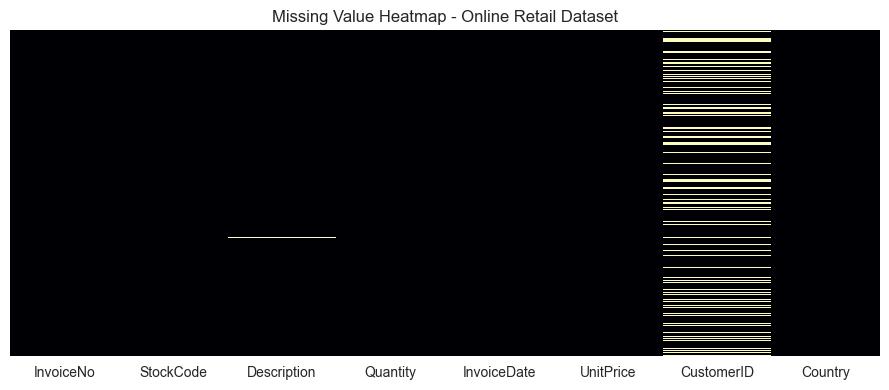

In [130]:
# Visualizing the missing values
plt.figure(figsize=(9,4))
sns.heatmap(df.isnull(), cbar=False, cmap='magma', yticklabels=False)
plt.title("Missing Value Heatmap - Online Retail Dataset")
plt.tight_layout()
plt.show()

### What did you know about your dataset?

Raw dataset: 541,909 rows, 8 columns -- InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country. Covers Dec 2022 to Dec 2023, 38 countries, 4,372 unique customers.

Found a bunch of data quality issues that need fixing before anything else: ~25% of rows have no CustomerID (guest checkouts I guess), some missing Descriptions, ~5.3k exact duplicates, ~9.3k cancelled orders (InvoiceNo starts with 'C'), and a chunk of rows with negative Quantity or zero/negative UnitPrice. Can't build customer-level features on top of any of this without cleaning it first.

## ***2. Understanding Your Variables***

In [131]:
# Dataset Columns
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [132]:
# Dataset Describe
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.00,NaN,NaN,NaN,9.55,218.08,-80995.00,1.00,3.00,10.00,80995.00
InvoiceDate,541909,23260,2023-10-31 14:41:00,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.00,NaN,NaN,NaN,4.61,96.76,-11062.06,1.25,2.08,4.13,38970.00
CustomerID,406829.00,NaN,NaN,NaN,15287.69,1713.60,12346.00,13953.00,15152.00,16791.00,18287.00
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

| Column | What it is |
|---|---|
| InvoiceNo | Transaction ID. 'C' prefix = cancelled order. |
| StockCode | Product code. |
| Description | Product name. |
| Quantity | Units bought on that line. Negative = return. |
| InvoiceDate | When the transaction happened. |
| UnitPrice | Price per unit in £. |
| CustomerID | Customer ID, missing for guest checkouts. |
| Country | Customer's country. |

Quantity × UnitPrice = revenue for that line, which I use later as TotalPrice and is the basis for the Monetary part of RFM.

### Check Unique Values for each variable.

In [133]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col:15s}: {df[col].nunique():>7,} unique values")

InvoiceNo      :  25,900 unique values
StockCode      :   4,070 unique values
Description    :   4,223 unique values
Quantity       :     722 unique values
InvoiceDate    :  23,260 unique values
UnitPrice      :   1,630 unique values
CustomerID     :   4,372 unique values
Country        :      38 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [134]:
# 1. Drop exact duplicate rows
df = df.drop_duplicates()

# 2. InvoiceNo as string (cancelled invoices are prefixed with 'C')
df['InvoiceNo'] = df['InvoiceNo'].astype(str)

# 3. Remove rows with missing CustomerID -- can't attribute the transaction to a customer
df = df.dropna(subset=['CustomerID'])

# 4. Remove rows with missing Description
df = df.dropna(subset=['Description'])

# 5. Exclude cancelled invoices (InvoiceNo starting with 'C'), per the project brief
df = df[~df['InvoiceNo'].str.startswith('C')]

# 6. Remove any remaining non-positive Quantity / UnitPrice rows (data errors)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# 7. Parse the date, engineer TotalPrice (line-item revenue), and fix CustomerID's dtype
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['CustomerID'] = df['CustomerID'].astype(int)

df = df.reset_index(drop=True)

print("Cleaned transaction data shape:", df.shape)
print("Unique customers :", df['CustomerID'].nunique())
print("Unique products   :", df['StockCode'].nunique())
print("Total net revenue : £{:,.2f}".format(df['TotalPrice'].sum()))

# 8. Build the customer-level RFM table -- the core feature table for this whole project
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

# 9. Attach each customer's primary country (most frequent country in their own transactions)
cust_country = df.groupby('CustomerID')['Country'].agg(lambda x: x.value_counts().index[0])
rfm = rfm.merge(cust_country.rename('Country'), on='CustomerID')
rfm['IsUK'] = np.where(rfm['Country'] == 'United Kingdom', 'UK', 'International')

# 9b. Log-transform Recency/Frequency/Monetary up front (they are heavily right-skewed this is needed by several later EDA charts as well as the modeling pipeline).
rfm['Recency_log'] = np.log1p(rfm['Recency'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

print("\nRFM table shape:", rfm.shape)

# 10. Rule-based RFM quartile scoring > segment labels.
#     This is BUSINESS LOGIC, not machine learning -- it exists purely to generate the ground-truth "Segment" labels that the supervised classifier in Section 7 will learn to predict.
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1]).astype(int)   # lower Recency = better = higher score
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4]).astype(int)
rfm['RFM_Score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

def label_segment(score):
    if score >= 10:
        return 'High-Value'
    elif score >= 8:
        return 'Regular'
    elif score >= 5:
        return 'Occasional'
    else:
        return 'At-Risk'

rfm['Segment'] = rfm['RFM_Score'].apply(label_segment)

print("\nSegment counts:")
print(rfm['Segment'].value_counts())
rfm.head()

Cleaned transaction data shape: (392692, 9)
Unique customers : 4338
Unique products   : 3665
Total net revenue : £8,887,208.89

RFM table shape: (4338, 9)

Segment counts:
Segment
Occasional    1420
High-Value    1267
Regular        845
At-Risk        806
Name: count, dtype: int64


,CustomerID,Recency,Frequency,Monetary,Country,IsUK,Recency_log,Frequency_log,Monetary_log,R_score,F_score,M_score,RFM_Score,Segment
0,12346,326,1,77183.60,United Kingdom,UK,5.79,0.69,11.25,1,1,4,6,Occasional
1,12347,2,7,4310.00,Iceland,International,1.10,2.08,8.37,4,4,4,12,High-Value
2,12348,75,4,1797.24,Finland,International,4.33,1.61,7.49,2,3,4,9,Regular
3,12349,19,1,1757.55,Italy,International,3.00,0.69,7.47,3,1,4,8,Regular
4,12350,310,1,334.40,Norway,International,5.74,0.69,5.82,1,1,2,4,At-Risk


### What all manipulations have you done and insights you found?

Dropped, in order: 5,268 duplicate rows, 135,080 rows with no CustomerID, 1,454 rows with no Description, 9,288 cancelled orders, and 40 more rows with bad Quantity/UnitPrice. Ended up with 392,692 usable rows -- 4,338 customers, £8.89M total revenue.

Built the RFM table from this (Recency/Frequency/Monetary per customer), attached each customer's country, and then labeled each customer into a segment using a quartile-scoring rule on R/F/M. That Segment column is what the classifier in section 7 is trained to predict -- everything else in this notebook builds toward that.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

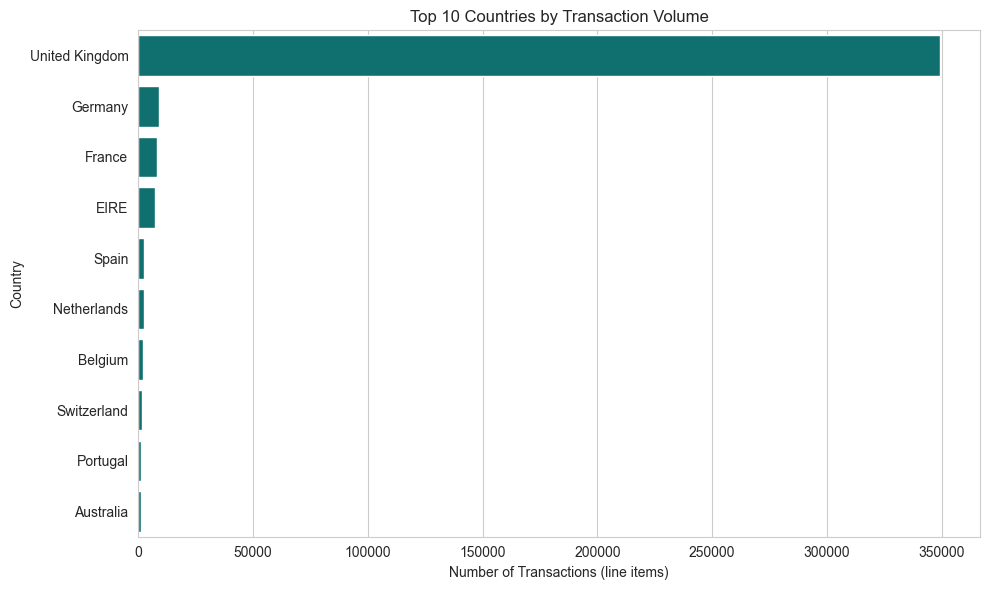

United Kingdom alone accounts for 88.9% of all transaction line items.


In [135]:
# Chart - 1 visualization code
top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index, color='teal')
plt.xlabel('Number of Transactions (line items)')
plt.ylabel('Country')
plt.title('Top 10 Countries by Transaction Volume')
plt.tight_layout()
plt.show()

print(f"United Kingdom alone accounts for {100*top_countries['United Kingdom']/len(df):.1f}% of all transaction line items.")

##### 1. Why did you pick the specific chart?

Bar chart, since I'm comparing transaction counts across countries and one country dominates -- a pie chart with 38 slices would just be unreadable.

##### 2. What is/are the insight(s) found from the chart?

UK is ~89% of all transactions. Germany, France and EIRE come next but each is under 3%.

##### 3. Will the gained insights help creating a positive business impact?

Basically confirms the business is UK-first. Makes sense to keep marketing/inventory focused there, and if international expansion is being considered, Germany/France/EIRE already show some organic demand so they'd be the logical next targets.

#### Chart - 2

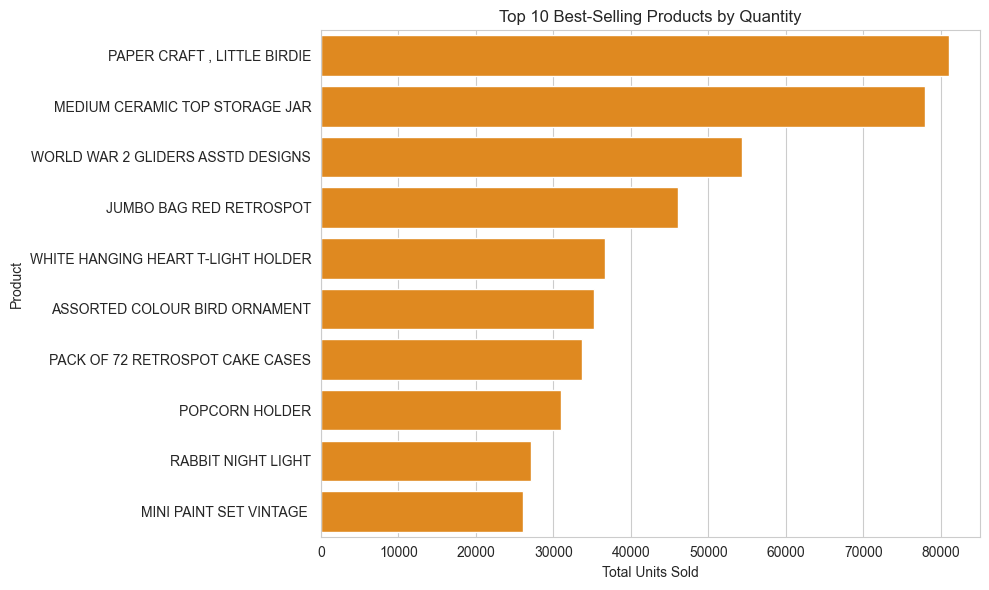

In [136]:
# Chart - 2 visualization code
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index, color='darkorange')
plt.xlabel('Total Units Sold')
plt.ylabel('Product')
plt.title('Top 10 Best-Selling Products by Quantity')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Horizontal bars again -- product names are long so this keeps them readable.

##### 2. What is/are the insight(s) found from the chart?

'PAPER CRAFT, LITTLE BIRDIE' and 'MEDIUM CERAMIC TOP STORAGE JAR' top the list at 78k-81k units each. Mostly cheap decor/novelty items in the top 10, not big-ticket stuff.

##### 3. Will the gained insights help creating a positive business impact?

These are the items that should never run out of stock. Also good candidates as 'seed' products for the recommender since so many customers have already bought them.

#### Chart - 3

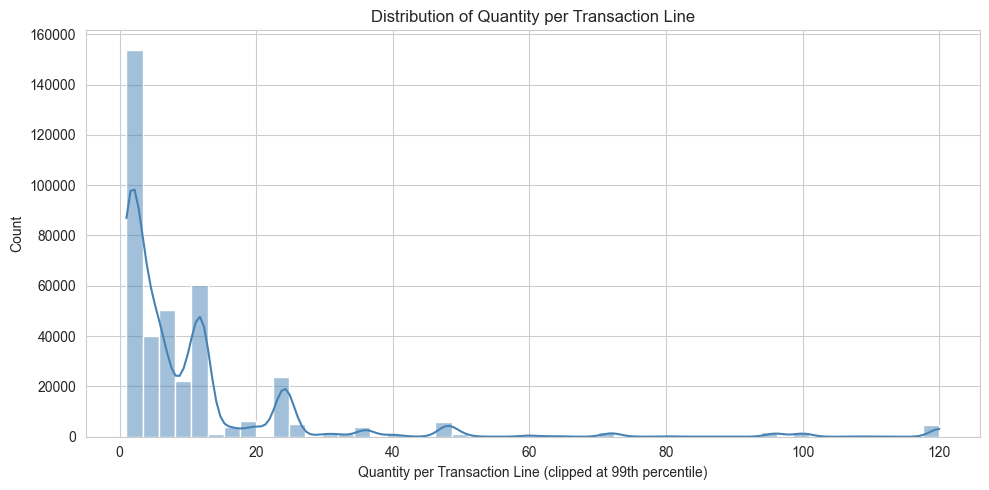

count   392692.00
mean        13.12
std        180.49
min          1.00
25%          2.00
50%          6.00
75%         12.00
max      80995.00
Name: Quantity, dtype: float64


In [137]:
# Chart - 3 visualization code
plt.figure(figsize=(10,5))
sns.histplot(df['Quantity'].clip(upper=df['Quantity'].quantile(0.99)), bins=50, kde=True, color='steelblue')
plt.xlabel('Quantity per Transaction Line (clipped at 99th percentile)')
plt.title('Distribution of Quantity per Transaction Line')
plt.tight_layout()
plt.show()

print(df['Quantity'].describe())

##### 1. Why did you pick the specific chart?

Histogram + KDE to see the shape of the distribution.

##### 2. What is/are the insight(s) found from the chart?

Heavily right-skewed -- median is 6 units per line but 99th percentile is over 100. A few bulk orders are dragging the mean way up.

##### 3. Will the gained insights help creating a positive business impact?

This skew is a heads up that Frequency/Monetary (built from this) will be skewed too, which is why I log-transform them later before scaling.

#### Chart - 4

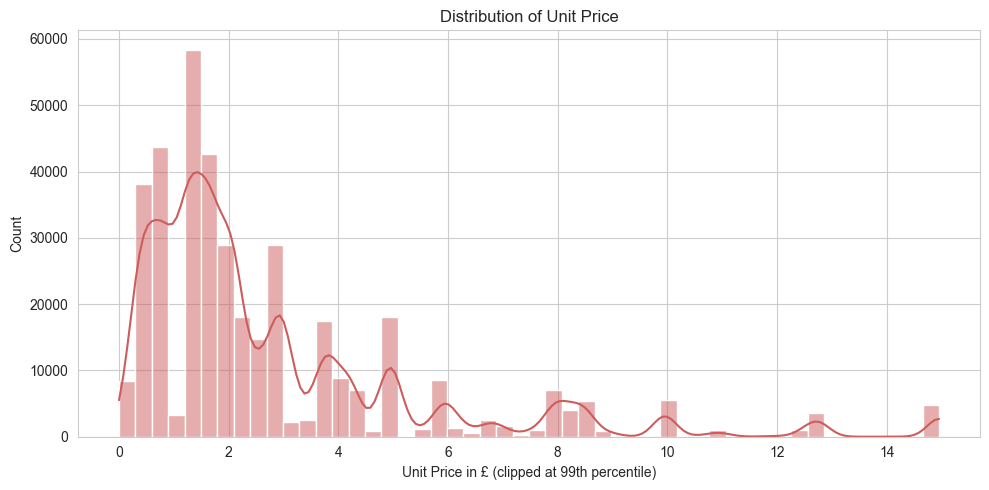

In [138]:
# Chart - 4 visualization code
plt.figure(figsize=(10,5))
sns.histplot(df['UnitPrice'].clip(upper=df['UnitPrice'].quantile(0.99)), bins=50, kde=True, color='indianred')
plt.xlabel('Unit Price in £ (clipped at 99th percentile)')
plt.title('Distribution of Unit Price')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Same logic as the Quantity chart -- histogram to check shape.

##### 2. What is/are the insight(s) found from the chart?

Most products are cheap (under £5), fits the catalog (home decor/novelty stuff). There's a long tail of expensive items but some of that turned out to be non-product rows like postage.

##### 3. Will the gained insights help creating a positive business impact?

Good reason to filter out non-product StockCodes (POST, M, etc.) before doing anything product-level -- handled later in outlier treatment and the recommender.

#### Chart - 5

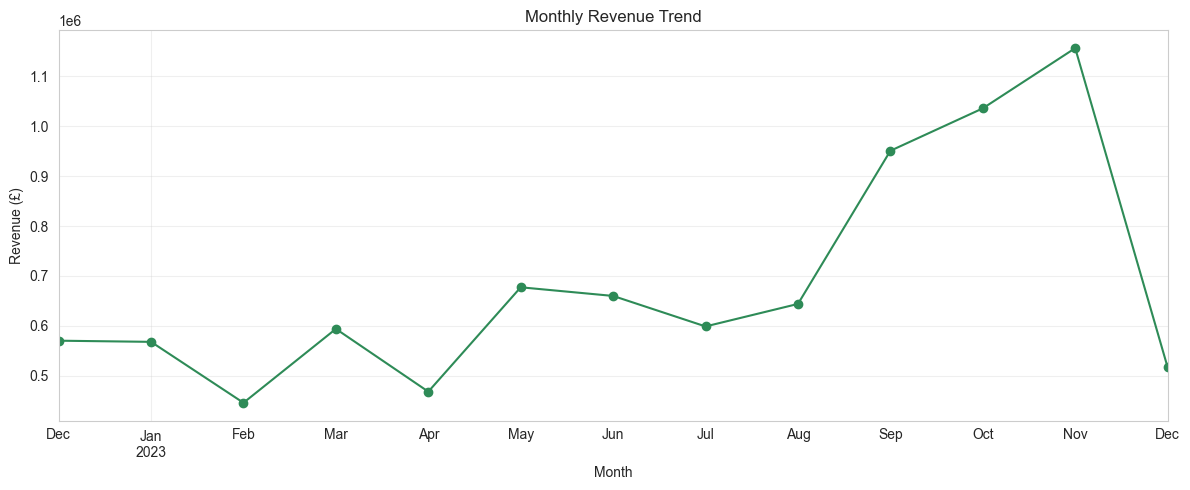

In [139]:
# Chart - 5 visualization code
monthly_revenue = df.set_index('InvoiceDate').resample('ME')['TotalPrice'].sum()

plt.figure(figsize=(12,5))
monthly_revenue.plot(marker='o', color='seagreen')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.title('Monthly Revenue Trend')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Line chart -- standard for time trends.

##### 2. What is/are the insight(s) found from the chart?

Revenue's steady most months (£450K-£680K) then jumps hard from September to November, peaking ~£1.16M in Nov. Classic pre-Christmas buildup. The December drop is misleading though -- dataset only has 9 days of Dec.

##### 3. Will the gained insights help creating a positive business impact?

Useful seasonality signal -- ramp up marketing/inventory from September. Just don't read that last data point as an actual decline, it's a data coverage thing.

#### Chart - 6

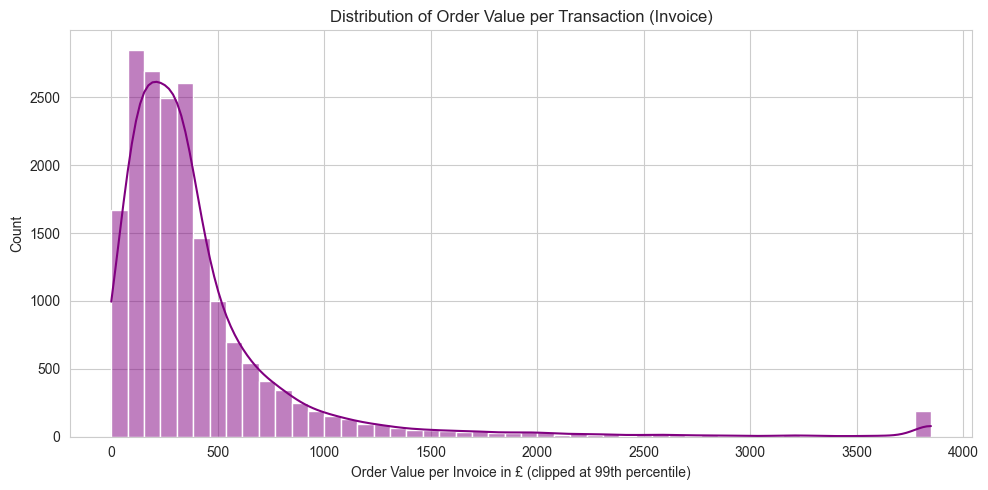

count    18532.00
mean       479.56
std       1678.08
min          0.38
25%        157.34
50%        302.57
75%        469.57
max     168469.60
Name: TotalPrice, dtype: float64


In [140]:
# Chart - 6 visualization code
invoice_totals = df.groupby('InvoiceNo')['TotalPrice'].sum()

plt.figure(figsize=(10,5))
sns.histplot(invoice_totals.clip(upper=invoice_totals.quantile(0.99)), bins=50, kde=True, color='purple')
plt.xlabel('Order Value per Invoice in £ (clipped at 99th percentile)')
plt.title('Distribution of Order Value per Transaction (Invoice)')
plt.tight_layout()
plt.show()

print(invoice_totals.describe())

##### 1. Why did you pick the specific chart?

Histogram of order value per invoice.

##### 2. What is/are the insight(s) found from the chart?

Median order is ~£303 but mean is £480 -- pulled up by a long tail, biggest single invoice is over £168k.

##### 3. Will the gained insights help creating a positive business impact?

Average order value alone would be misleading here. Median (or proper RFM segmentation, which I do later) gives a more honest picture of what a 'typical' order actually looks like.

#### Chart - 7

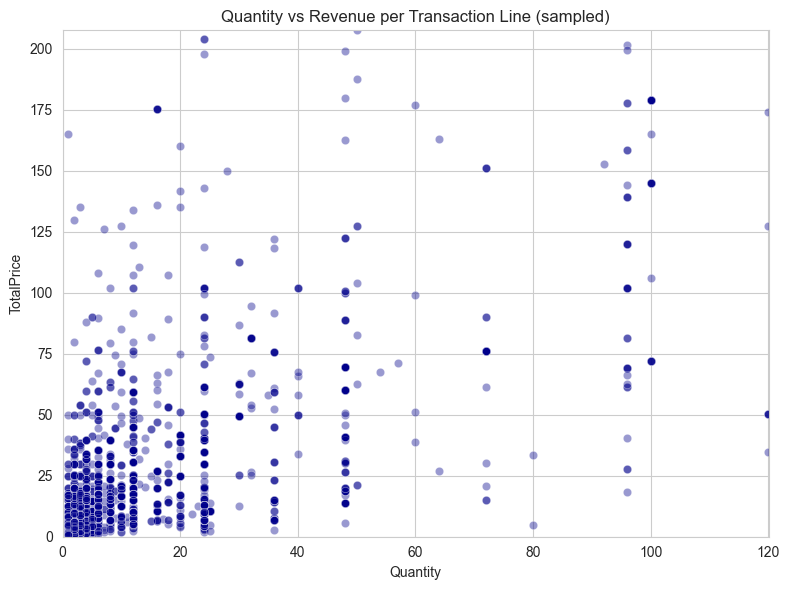

In [141]:
# Chart - 7 visualization code
sample = df.sample(5000, random_state=42)

plt.figure(figsize=(8,6))
sns.scatterplot(data=sample, x='Quantity', y='TotalPrice', alpha=0.4, color='darkblue')
plt.xlim(0, sample['Quantity'].quantile(0.99))
plt.ylim(0, sample['TotalPrice'].quantile(0.99))
plt.title('Quantity vs Revenue per Transaction Line (sampled)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Scatter plot for two numeric variables (Quantity vs Revenue), sampled 5000 rows so it's not a blob.

##### 2. What is/are the insight(s) found from the chart?

Positive relationship obviously (TotalPrice = Quantity × UnitPrice), but the spread shows some high-revenue lines come from a few expensive items, not bulk quantity.

##### 3. Will the gained insights help creating a positive business impact?

Mostly a sanity check -- confirms revenue depends on both volume and price, which is why I treat Monetary as its own RFM dimension instead of assuming order count covers it.

#### Chart - 8

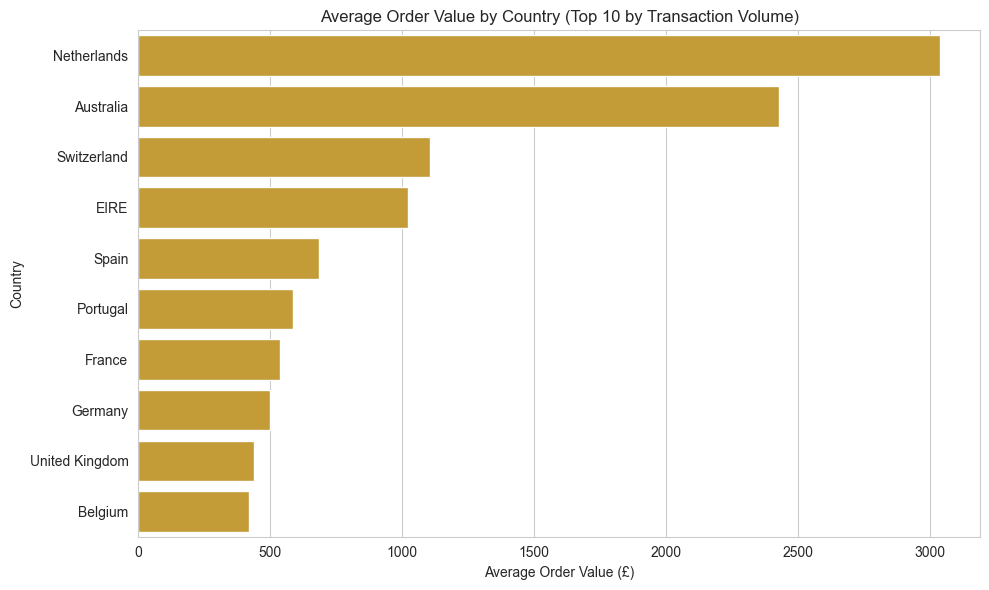

In [142]:
# Chart - 8 visualization code
top10_country_list = df['Country'].value_counts().head(10).index
avg_order_by_country = (
    df[df['Country'].isin(top10_country_list)]
    .groupby(['InvoiceNo', 'Country'])['TotalPrice'].sum()
    .reset_index()
    .groupby('Country')['TotalPrice'].mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
sns.barplot(x=avg_order_by_country.values, y=avg_order_by_country.index, color='goldenrod')
plt.xlabel('Average Order Value (£)')
plt.ylabel('Country')
plt.title('Average Order Value by Country (Top 10 by Transaction Volume)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart, average order value across top 10 countries by volume.

##### 2. What is/are the insight(s) found from the chart?

Average order value varies a fair bit even within the top 10 -- some smaller international markets actually order bigger baskets per invoice than the UK average.

##### 3. Will the gained insights help creating a positive business impact?

High-volume-low-basket (UK) and low-volume-high-basket (some international) markets need different strategies -- frequency-driving tactics for the former, upsell/bundle stuff for the latter.

#### Chart - 9

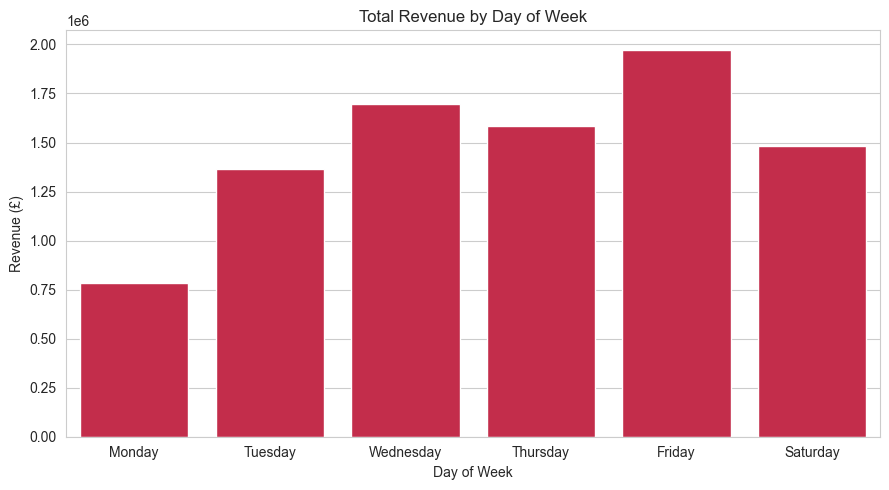

In [143]:
# Chart - 9 visualization code
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
revenue_by_day = df.groupby('DayOfWeek')['TotalPrice'].sum().reindex(day_order).dropna()

plt.figure(figsize=(9,5))
sns.barplot(x=revenue_by_day.index, y=revenue_by_day.values, color='crimson')
plt.xlabel('Day of Week')
plt.ylabel('Revenue (£)')
plt.title('Total Revenue by Day of Week')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart over day of week.

##### 2. What is/are the insight(s) found from the chart?

Friday's the best revenue day, then Wednesday/Thursday. Monday's weakest. Zero transactions on Sunday -- business just doesn't operate that day.

##### 3. Will the gained insights help creating a positive business impact?

Useful for scheduling promos/emails around Wed-Fri. Also need to remember the Sunday gap isn't a real zero-demand day if doing any forecasting later.

#### Chart - 10

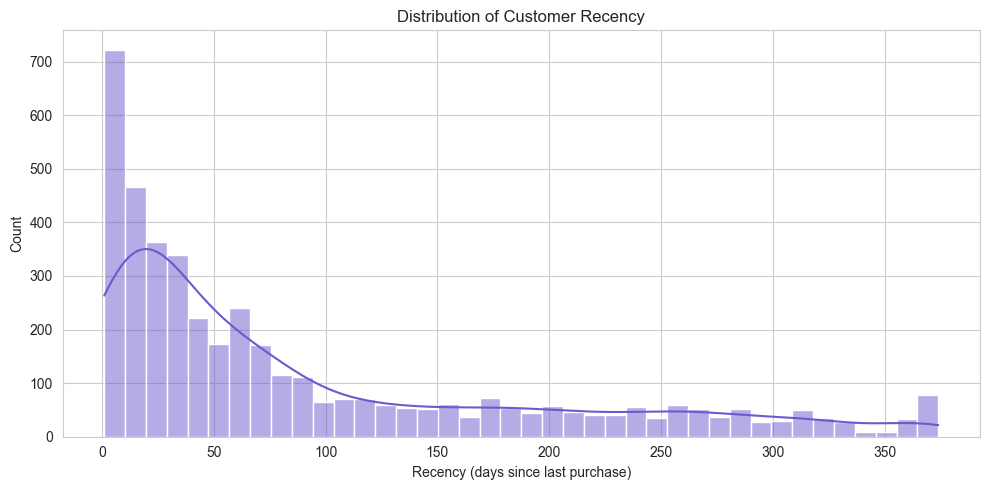

In [144]:
# Chart - 10 visualization code
plt.figure(figsize=(10,5))
sns.histplot(rfm['Recency'], bins=40, kde=True, color='slateblue')
plt.xlabel('Recency (days since last purchase)')
plt.title('Distribution of Customer Recency')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Recency is one of the 3 RFM features so I want to see its shape before using it.

##### 2. What is/are the insight(s) found from the chart?

Right-skewed but not as bad as Frequency/Monetary -- a lot of customers bought recently (under 20 days), but there's a real tail of people who haven't purchased in 6-12 months.

##### 3. Will the gained insights help creating a positive business impact?

That tail is exactly who a win-back campaign should target before they're gone for good -- this is basically what becomes the At-Risk segment later.

#### Chart - 11

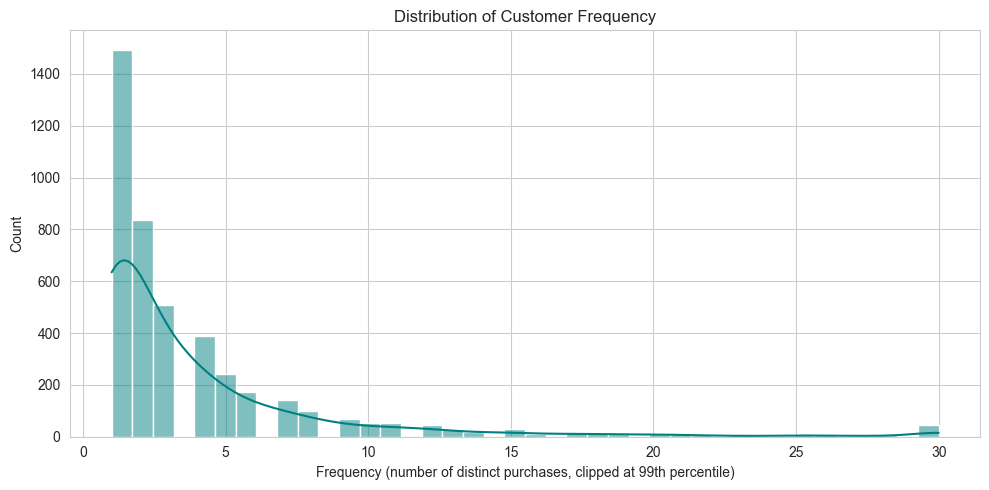

In [145]:
# Chart - 11 visualization code
plt.figure(figsize=(10,5))
sns.histplot(rfm['Frequency'].clip(upper=rfm['Frequency'].quantile(0.99)), bins=40, kde=True, color='teal')
plt.xlabel('Frequency (number of distinct purchases, clipped at 99th percentile)')
plt.title('Distribution of Customer Frequency')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Same check as Recency, now for Frequency.

##### 2. What is/are the insight(s) found from the chart?

Very skewed (skewness ~12). More than half the customers bought only 1-2 times ever, while a small set of repeat buyers placed 50-200+ orders.

##### 3. Will the gained insights help creating a positive business impact?

Strongest evidence in the whole EDA that I need a log transform before modeling -- otherwise those extreme repeat buyers would dominate everything.

#### Chart - 12

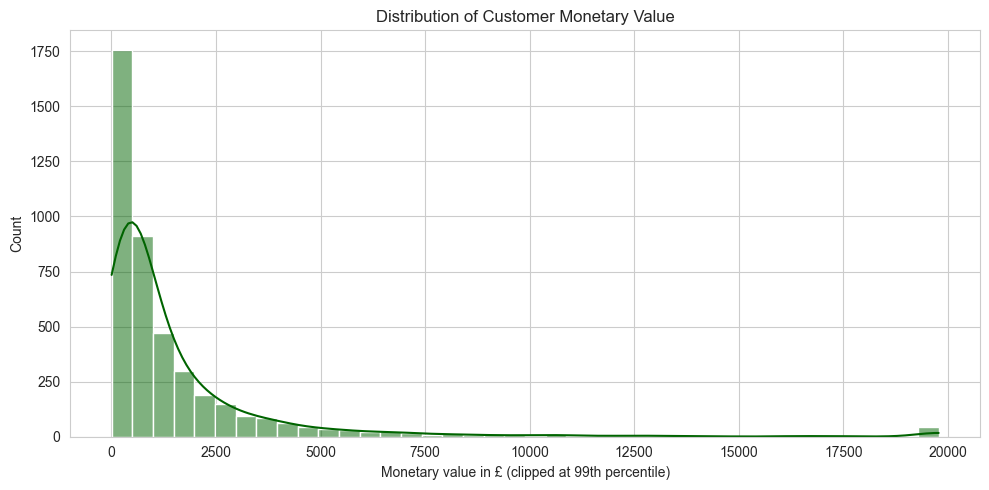

In [146]:
# Chart - 12 visualization code
plt.figure(figsize=(10,5))
sns.histplot(rfm['Monetary'].clip(upper=rfm['Monetary'].quantile(0.99)), bins=40, kde=True, color='darkgreen')
plt.xlabel('Monetary value in £ (clipped at 99th percentile)')
plt.title('Distribution of Customer Monetary Value')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Same check, now Monetary.

##### 2. What is/are the insight(s) found from the chart?

Even more skewed than Frequency (skewness ~19). Median spend is ~£669 but top spenders are well over £100k, one customer above £280k.

##### 3. Will the gained insights help creating a positive business impact?

These aren't errors, they're genuinely valuable customers -- don't want to remove them, just compress the scale with a log transform so they don't dominate the model.

#### Chart - 13

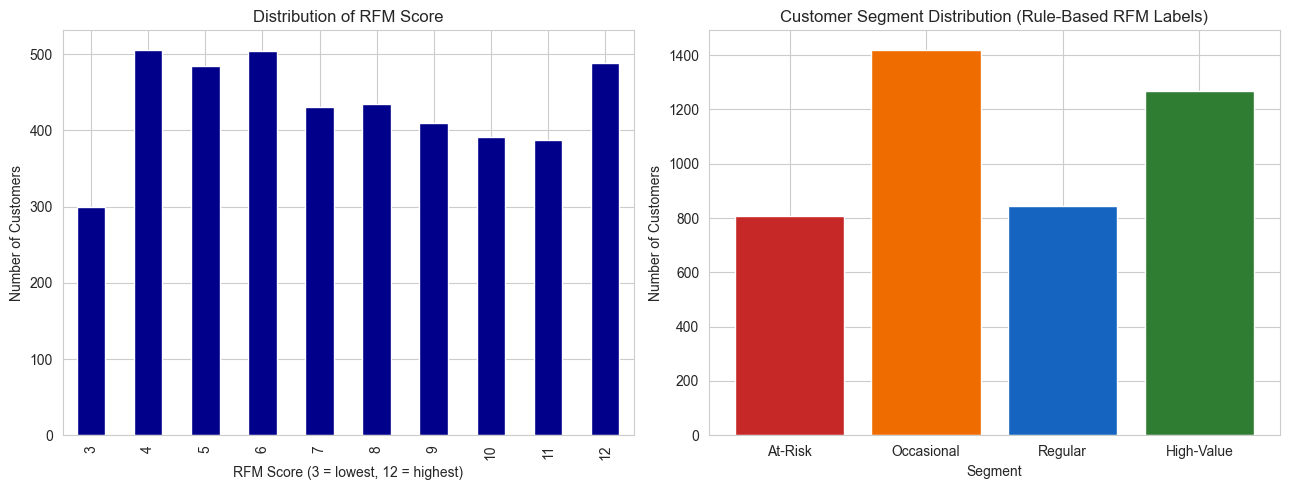

Segment
At-Risk        806
Occasional    1420
Regular        845
High-Value    1267
Name: count, dtype: int64


In [147]:
# Chart - 13 visualization code
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

rfm['RFM_Score'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='darkblue')
axes[0].set_xlabel('RFM Score (3 = lowest, 12 = highest)')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Distribution of RFM Score')

segment_order = ['At-Risk', 'Occasional', 'Regular', 'High-Value']
segment_counts = rfm['Segment'].value_counts().reindex(segment_order)
axes[1].bar(segment_order, segment_counts.values, color=['#c62828', '#ef6c00', '#1565c0', '#2e7d32'])
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Customer Segment Distribution (Rule-Based RFM Labels)')
plt.tight_layout()
plt.show()

print(segment_counts)

##### 1. Why did you pick the specific chart?

Bar charts for RFM_Score and the resulting Segment counts -- this is literally the classification target for Section 7, so worth checking its distribution early.

##### 2. What is/are the insight(s) found from the chart?

RFM_Score is spread fairly evenly across 3-12, no big spike anywhere. After mapping to segments: Occasional (32.7%) and High-Value (29.2%) are the two biggest, Regular (19.5%) and At-Risk (18.6%) smaller.

##### 3. Will the gained insights help creating a positive business impact?

Since this becomes the classifier's target, it's worth flagging mild class imbalance here (biggest class is ~1.8x the smallest). Not bad enough for SMOTE but worth handling with stratified splits + class_weight, which I do in Feature Engineering.

#### Chart - 14 - Correlation Heatmap

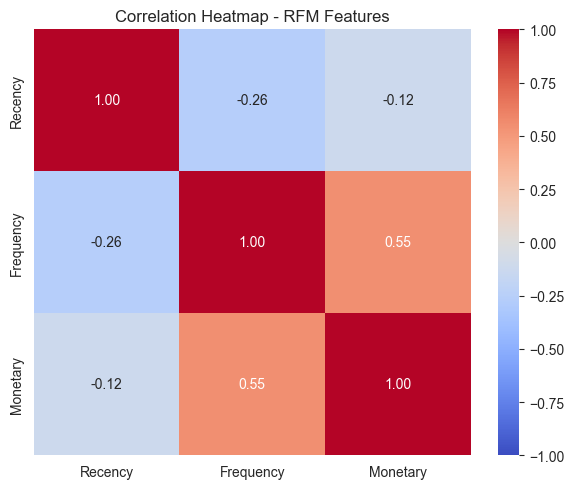

In [148]:
# Correlation Heatmap visualization code
plt.figure(figsize=(6, 5))
sns.heatmap(rfm[['Recency', 'Frequency', 'Monetary']].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap - RFM Features')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Quick way to check if the 3 RFM features are redundant before feeding them into a model together.

##### 2. What is/are the insight(s) found from the chart?

Frequency and Monetary are moderately correlated (~0.55) which makes sense -- buy more often, spend more overall. Recency is mildly negatively correlated with both (-0.26 with Frequency, -0.12 with Monetary). Nothing strong enough to drop a feature.

#### Chart - 15 - Pair Plot

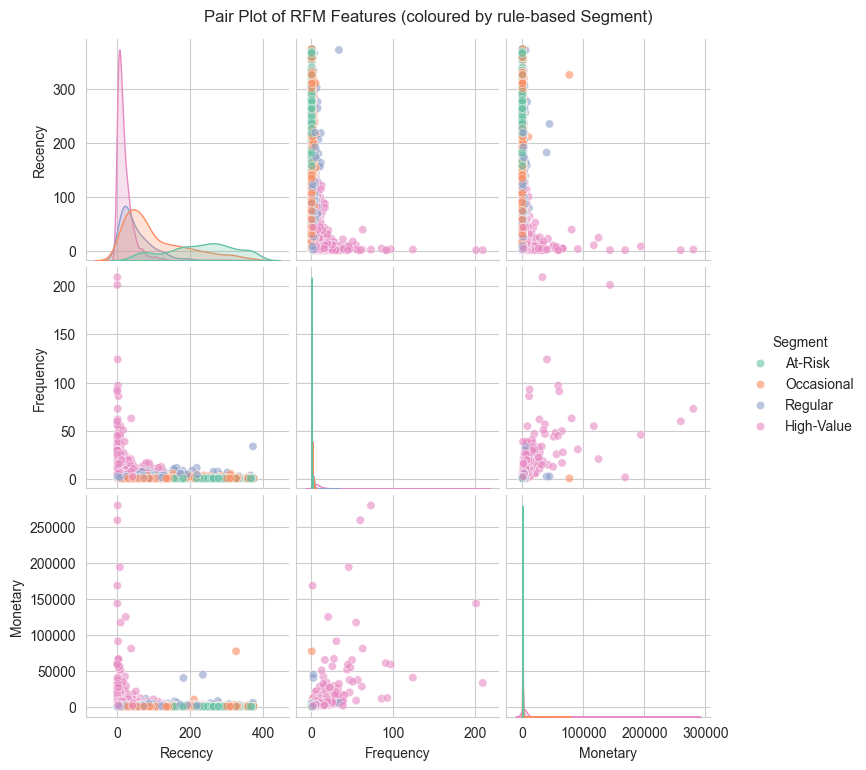

In [149]:
# Pair Plot visualization code
sns.pairplot(
    rfm, vars=['Recency', 'Frequency', 'Monetary'], hue='Segment', hue_order=['At-Risk', 'Occasional', 'Regular', 'High-Value'],
    palette='Set2', diag_kind='kde', plot_kws={'alpha': 0.6}
)
plt.suptitle('Pair Plot of RFM Features (coloured by rule-based Segment)', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

Pair plot colored by Segment -- lets me check all 3 RFM features against each other at once and see how separable the segments actually look before training anything.

##### 2. What is/are the insight(s) found from the chart?

Segments are visibly separated, mostly along Monetary/Frequency -- High-Value sits at high Freq/Monetary and low Recency, At-Risk is the opposite. Regular and Occasional sit in between. Good sign that a classifier should be able to learn this boundary reasonably well.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Three things I wanted to check statistically before moving to modeling:
1. Does the High-Value segment actually spend significantly more than everyone else? (t-test)
2. Is segment membership related to UK vs International? (chi-square)
3. Are Frequency and Recency actually correlated the way I'd expect? (Spearman)

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0:** No difference in average Monetary spend between High-Value and everyone else.
**H1:** High-Value segment spends significantly more.

#### 2. Perform an appropriate statistical test.

In [150]:
# Perform Statistical Test to obtain P-Value
group_top = rfm[rfm['Segment'] == 'High-Value']['Monetary']
group_rest = rfm[rfm['Segment'] != 'High-Value']['Monetary']

t_stat, p_value = stats.ttest_ind(group_top, group_rest, equal_var=False)

print(f"High-Value segment mean Monetary : £{group_top.mean():,.2f}  (n={len(group_top)})")
print(f"All other customers mean Monetary : £{group_rest.mean():,.2f}  (n={len(group_rest)})")
print(f"t-statistic = {t_stat:.3f}")
print(f"p-value     = {p_value:.3e}")

High-Value segment mean Monetary : £5,388.50  (n=1267)
All other customers mean Monetary : £670.78  (n=3071)
t-statistic = 10.543
p-value     = 5.565e-25


##### Which statistical test have you done to obtain P-Value?

Welch's t-test (doesn't assume equal variance between the two groups).

##### Why did you choose the specific statistical test?

Going with Welch's instead of a regular t-test because the High-Value group has way more spread (a few huge spenders) than the rest -- assuming equal variance here would be wrong.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0:** Segment is independent of UK/International status.
**H1:** There's a significant association between segment and UK/International status.

#### 2. Perform an appropriate statistical test.

In [151]:
# Perform Statistical Test to obtain P-Value
contingency = pd.crosstab(rfm['IsUK'], rfm['Segment'])
print(contingency)
print()

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-square statistic = {chi2:.3f}")
print(f"Degrees of freedom    = {dof}")
print(f"p-value               = {p_value:.5f}")

Segment        At-Risk  High-Value  Occasional  Regular
IsUK                                                   
International       63         130         143       82
UK                 743        1137        1277      763

Chi-square statistic = 3.945
Degrees of freedom    = 3
p-value               = 0.26751


##### Which statistical test have you done to obtain P-Value?

Chi-square test of independence.

##### Why did you choose the specific statistical test?

Both variables are categorical (Segment, UK/International), so chi-square is the right call here. Result: p = 0.268, so I can't reject the null -- segment and geography aren't significantly related in this data. Honestly didn't expect that going in, but it's a useful result: means I don't need Country as a feature for the classifier.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0:** No monotonic correlation between Frequency and Recency.
**H1:** There's a significant monotonic correlation between them.

#### 2. Perform an appropriate statistical test.

In [152]:
# Perform Statistical Test to obtain P-Value
rho, p_value = stats.spearmanr(rfm['Frequency'], rfm['Recency'])

print(f"Spearman correlation (Frequency vs Recency) = {rho:.4f}")
print(f"p-value = {p_value:.3e}")

Spearman correlation (Frequency vs Recency) = -0.5624
p-value = 0.000e+00


##### Which statistical test have you done to obtain P-Value?

Spearman's rank correlation.

##### Why did you choose the specific statistical test?

Frequency is really skewed and the relationship with Recency isn't necessarily linear, so Pearson would be the wrong tool here. Spearman just needs a monotonic relationship and works on ranks so it's robust to the skew/outliers I found earlier.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [153]:
# Handling Missing Values & Missing Value Imputation
# Missing values were already handled during Data Wrangling (Section 3): rows with a missing
# CustomerID or Description were dropped rather than imputed. Re-confirming here that the
# working tables are clean before any further feature engineering.
print("Missing values in transaction data (df):")
print(df.isnull().sum())
print()
print("Missing values in customer-level RFM table (rfm):")
print(rfm.isnull().sum())

Missing values in transaction data (df):
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
DayOfWeek      0
dtype: int64

Missing values in customer-level RFM table (rfm):
CustomerID       0
Recency          0
Frequency        0
Monetary         0
Country          0
IsUK             0
Recency_log      0
Frequency_log    0
Monetary_log     0
R_score          0
F_score          0
M_score          0
RFM_Score        0
Segment          0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

Already handled missing values back in Data Wrangling by dropping rows -- just double-checking here that nothing slipped through.

### 2. Handling Outliers

In [154]:
# Handling Outliers & Outlier treatments
from scipy.stats import skew

print("Raw skewness:")
print(f"  Recency  : {skew(rfm['Recency']):.2f}")
print(f"  Frequency: {skew(rfm['Frequency']):.2f}")
print(f"  Monetary : {skew(rfm['Monetary']):.2f}")
print()
print("Skewness after log1p transform:")
print(f"  Recency_log  : {skew(rfm['Recency_log']):.2f}")
print(f"  Frequency_log: {skew(rfm['Frequency_log']):.2f}")
print(f"  Monetary_log : {skew(rfm['Monetary_log']):.2f}")
print()

# Non-product administrative StockCodes (e.g. postage, manual adjustments) are not real
# catalog items and would distort product-level analysis (top sellers, recommendations).
ADMIN_CODES = ['POST', 'M', 'C2', 'DOT', 'BANK CHARGES', 'PADS', 'CRUK']
n_admin_rows = df['StockCode'].str.upper().isin(ADMIN_CODES).sum()
print(f"Non-product administrative rows found: {n_admin_rows} ({100*n_admin_rows/len(df):.2f}% of transactions)")
print("These are excluded specifically when building the product recommendation engine (Section 7, ML Model - 3).")

Raw skewness:
  Recency  : 1.25
  Frequency: 12.06
  Monetary : 19.33

Skewness after log1p transform:
  Recency_log  : -0.38
  Frequency_log: 1.21
  Monetary_log : 0.40

Non-product administrative rows found: 1542 (0.39% of transactions)
These are excluded specifically when building the product recommendation engine (Section 7, ML Model - 3).


##### What all outlier treatment techniques have you used and why did you use those techniques?

Two different outlier strategies, deliberately. The extreme high-spend/high-frequency customers in the RFM data aren't errors -- they're literally the customers I'm trying to identify as High-Value -- so I kept them and just log-transformed instead of removing/capping. Separately, a few StockCodes (POST, M, etc.) are postage/admin fees, not real products, and I exclude those specifically when building the recommender since they'd mess up the similarity matrix.

### 3. Categorical Encoding

In [155]:
# Encode your categorical columns
# Country has 38 levels and is used here mainly for descriptive/hypothesis-testing purposes,
# not as a model input (the segment classifier only uses the numeric RFM features).
# A simple binary encoding (IsUK) was already created during Data Wrangling and is demonstrated
# here as a label-encoding example for completeness.
le = LabelEncoder()
rfm['IsUK_encoded'] = le.fit_transform(rfm['IsUK'])
print(dict(zip(le.classes_, le.transform(le.classes_))))
rfm[['CustomerID', 'Country', 'IsUK', 'IsUK_encoded']].head()

{'International': 0, 'UK': 1}


,CustomerID,Country,IsUK,IsUK_encoded
0,12346,United Kingdom,UK,1
1,12347,Iceland,International,0
2,12348,Finland,International,0
3,12349,Italy,International,0
4,12350,Norway,International,0


#### What all categorical encoding techniques have you used & why did you use those techniques?

Used label encoding for the IsUK flag (just 2 categories, no order implied). Didn't one-hot encode the full Country column into the classifier features though -- the segmentation is meant to be driven by purchase behavior, not geography, and the hypothesis test already showed Segment isn't related to UK/International anyway. Keeping Country around just for descriptive stuff.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

**Not core to this project** -- there is no NLP/sentiment/text-classification target here; the recommendation engine is built from the customer-item purchase matrix, not from product description text.

#### 1. Expand Contraction

In [156]:
# Expand Contraction
# Product names in this dataset are short catalog titles (e.g. "WHITE HANGING HEART T-LIGHT
# HOLDER") and essentially never contain English contractions (it's, don't, etc.), so this
# step is implemented generically but has no visible effect on this particular text column.
def expand_contractions(text):
    contraction_map = {"n't": " not", "'re": " are", "'s": " is", "'ll": " will", "'ve": " have"}
    for k, v in contraction_map.items():
        text = text.replace(k, v)
    return text

sample_descriptions = df['Description'].drop_duplicates().head(5)
sample_descriptions.apply(expand_contractions)

0     WHITE HANGING HEART T-LIGHT HOLDER
1                    WHITE METAL LANTERN
2         CREAM CUPID HEARTS COAT HANGER
3    KNITTED UNION FLAG HOT WATER BOTTLE
4         RED WOOLLY HOTTIE WHITE HEART.
Name: Description, dtype: object

#### 2. Lower Casing

In [157]:
# Lower Casing
product_text = df['Description'].drop_duplicates().reset_index(drop=True)
product_text_clean = product_text.str.lower()
product_text_clean.head()

0     white hanging heart t-light holder
1                    white metal lantern
2         cream cupid hearts coat hanger
3    knitted union flag hot water bottle
4         red woolly hottie white heart.
Name: Description, dtype: object

#### 3. Removing Punctuations

In [158]:
# Remove Punctuations
product_text_clean = product_text_clean.str.translate(str.maketrans('', '', string.punctuation))
product_text_clean.head()

0      white hanging heart tlight holder
1                    white metal lantern
2         cream cupid hearts coat hanger
3    knitted union flag hot water bottle
4          red woolly hottie white heart
Name: Description, dtype: object

#### 4. Removing URLs & Removing words and digits contain digits.

In [159]:
# Remove URLs & Remove words and digits contain digits
# Product descriptions in this catalog don't contain URLs; this still runs the standard regex
# so the pipeline is robust if it's ever reused on noisier text.
product_text_clean = product_text_clean.apply(lambda x: re.sub(r'http\S+|www\S+', '', x))
product_text_clean = product_text_clean.apply(lambda x: re.sub(r'\w*\d\w*', '', x))
product_text_clean = product_text_clean.str.strip()
product_text_clean.head()

0      white hanging heart tlight holder
1                    white metal lantern
2         cream cupid hearts coat hanger
3    knitted union flag hot water bottle
4          red woolly hottie white heart
Name: Description, dtype: object

#### 5. Removing Stopwords & Removing White spaces

In [160]:
# Remove Stopwords
try:
    import nltk
    nltk.data.find('corpora/stopwords')
    from nltk.corpus import stopwords
    stop_words = set(stopwords.words('english'))
except Exception:
    # Fallback small stopword list if NLTK data isn't available in this environment
    stop_words = {'a','an','the','of','for','and','in','on','with','to','at'}

product_text_clean = product_text_clean.apply(
    lambda x: ' '.join([w for w in x.split() if w not in stop_words])
)
product_text_clean.head()

0      white hanging heart tlight holder
1                    white metal lantern
2         cream cupid hearts coat hanger
3    knitted union flag hot water bottle
4          red woolly hottie white heart
Name: Description, dtype: object

In [161]:
# Remove White spaces
product_text_clean = product_text_clean.apply(lambda x: re.sub(r'\s+', ' ', x).strip())
product_text_clean.head()

0      white hanging heart tlight holder
1                    white metal lantern
2         cream cupid hearts coat hanger
3    knitted union flag hot water bottle
4          red woolly hottie white heart
Name: Description, dtype: object

#### 6. Rephrase Text

In [162]:
# Rephrase Text
# Not applicable -- this is a paraphrasing/summarisation step meant for longer free-text
# (reviews, descriptions of paragraph length). Product titles here are already short, fixed
# catalog names, so rephrasing them would only destroy the exact-match lookup the
# recommendation engine relies on.

#### 7. Tokenization

In [163]:
# Tokenization
product_text_clean.head().apply(lambda x: x.split())

0       [white, hanging, heart, tlight, holder]
1                       [white, metal, lantern]
2          [cream, cupid, hearts, coat, hanger]
3    [knitted, union, flag, hot, water, bottle]
4           [red, woolly, hottie, white, heart]
Name: Description, dtype: object

#### 8. Text Normalization

In [164]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
try:
    import nltk
    nltk.data.find('corpora/wordnet')
    from nltk.stem import WordNetLemmatizer
    lemmatizer = WordNetLemmatizer()
    product_text_norm = product_text_clean.apply(
        lambda x: ' '.join([lemmatizer.lemmatize(w) for w in x.split()])
    )
except Exception:
    # Fallback: simple stemming-free pass-through if NLTK wordnet data isn't available
    product_text_norm = product_text_clean

product_text_norm.head()

0      white hanging heart tlight holder
1                    white metal lantern
2         cream cupid hearts coat hanger
3    knitted union flag hot water bottle
4          red woolly hottie white heart
Name: Description, dtype: object

##### Which text normalization technique have you used and why?

Lemmatization over stemming, mainly because stemming can mangle words into non-words ("holder" → "hold") which makes a product lookup table harder to read. Lemmatization keeps actual words.

#### 9. Part of speech tagging

In [165]:
# POS Taging
try:
    import nltk
    nltk.data.find('taggers/averaged_perceptron_tagger')
    sample_tagged = nltk.pos_tag(product_text_norm.iloc[0].split())
    print(sample_tagged)
except Exception:
    print("POS tagger data not available in this environment; skipping (not required for this project's modeling).")

[('white', 'JJ'), ('hanging', 'VBG'), ('heart', 'NN'), ('tlight', 'NN'), ('holder', 'NN')]


#### 10. Text Vectorization

In [166]:
# Vectorizing Text
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=500)
product_tfidf_matrix = tfidf.fit_transform(product_text_norm)
print("TF-IDF matrix shape:", product_tfidf_matrix.shape)

TF-IDF matrix shape: (3877, 500)


##### Which text vectorization technique have you used and why?

TF-IDF instead of plain CountVectorizer because it down-weights generic words that show up in almost every product title. Though honestly this TF-IDF matrix doesn't end up being used by the final recommender -- the collaborative filtering approach (actual purchase co-occurrence) works better than text similarity for "bought together" style recommendations, so this section is more of a demonstration than something that feeds the final model.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [167]:
# Manipulate Features to minimize feature correlation and create new features
# AvgOrderValue is a derived feature (Monetary / Frequency) that captures how big a customer's
# typical basket is, independent of how often they shop -- useful context even though it isn't
# fed into the classifier directly (Frequency and Monetary already capture that jointly).
rfm['AvgOrderValue'] = (rfm['Monetary'] / rfm['Frequency']).round(2)
rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'AvgOrderValue']].head()

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue
0,12346,326,1,77183.60,77183.60
1,12347,2,7,4310.00,615.71
2,12348,75,4,1797.24,449.31
3,12349,19,1,1757.55,1757.55
4,12350,310,1,334.40,334.40


#### 2. Feature Selection

In [168]:
# Select your features wisely to avoid overfitting
# Only the three log-transformed RFM features are used as the classifier's inputs. Raw (unlogged)
# RFM columns and the derived AvgOrderValue are kept in the table for reporting/explainability,
# but are intentionally excluded from the model input to avoid redundancy and to keep the
# classifier driven purely by the well-understood, business-defined RFM dimensions (the same
# three features the rule-based Segment label itself was derived from).
classification_features = ['Recency_log', 'Frequency_log', 'Monetary_log']
print("Features selected for the classifier:", classification_features)

Features selected for the classifier: ['Recency_log', 'Frequency_log', 'Monetary_log']


##### What all feature selection methods have you used  and why?

Didn't run any automated feature selection (RFE etc.) -- there's only 3 candidate features and they're all the business-mandated RFM dimensions anyway. Kept the log-transformed trio for the model, kept the raw values around just for readable reporting.

##### Which all features you found important and why?

All three RFM features (log-transformed) were kept. They're the core of the whole project and the correlation check earlier confirmed none of them are redundant (max correlation was 0.55). The classifier's feature importances later confirm all three matter roughly equally.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [169]:
# Transform Your data
# Already computed during Data Wrangling, repeated here for the formal pre-processing record.
rfm['Recency_log'] = np.log1p(rfm['Recency'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

print("Yes, the data needed transforming -- Frequency and Monetary are heavily right-skewed")
print("(raw skewness ~12 and ~19 respectively). A log1p transform was applied to compress the")
print("scale of extreme values without discarding genuinely high-value customers.")

Yes, the data needed transforming -- Frequency and Monetary are heavily right-skewed
(raw skewness ~12 and ~19 respectively). A log1p transform was applied to compress the
scale of extreme values without discarding genuinely high-value customers.


### 6. Data Scaling

In [170]:
# Scaling your data
scaler_fe = StandardScaler()
X_scaled = scaler_fe.fit_transform(rfm[classification_features])

print("Scaled feature matrix shape:", X_scaled.shape)
print("Mean (should be ~0):", X_scaled.mean(axis=0).round(4))
print("Std  (should be ~1):", X_scaled.std(axis=0).round(4))

Scaled feature matrix shape: (4338, 3)
Mean (should be ~0): [-0. -0. -0.]
Std  (should be ~1): [1. 1. 1.]


##### Which method have you used to scale you data and why?

StandardScaler, after the log transform. Logistic Regression (one of the two models I train) is sensitive to feature scale since it works off a weighted sum -- without scaling, Monetary (in the thousands) would dominate over Recency (in the hundreds) just because of its bigger raw numbers, not because it's actually more important. Random Forest doesn't really need scaling but I used the same scaled input for both so the comparison is fair.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Didn't really need dimensionality reduction for the model itself -- only 3 features, all meaningful. PCA is used below purely so I can plot the segments on a 2D scatter, not as model input.

In [171]:
# DImensionality Reduction (If needed)
# X_scaled was already computed in the Data Scaling step above; reused here directly.
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_scaled)
rfm['PCA1'] = pca_components[:, 0]
rfm['PCA2'] = pca_components[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_.round(4))
print("Total variance captured by 2 components:", round(pca.explained_variance_ratio_.sum()*100, 2), "%")

Explained variance ratio: [0.7508 0.1879]
Total variance captured by 2 components: 93.87 %


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

2 PCA components capture ~93.9% of the variance (75.1% on PC1 alone), so the 2D plot is a pretty faithful picture of how separated the segments are. The actual classifier still trains on the 3 original scaled features though, not the PCA components -- keeps the feature importances interpretable.

### 8. Data Splitting

In [172]:
# Split your data to train and test. Choose Splitting ratio wisely.
# This IS a genuine supervised classification problem -- the rule-based Segment label is the
# target. A stratified 80/20 split is used so that all four segment classes keep roughly the
# same proportion in both the train and test sets.
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(rfm['Segment'])

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print("Train customers:", X_train.shape[0])
print("Test (holdout) customers :", X_test.shape[0])
print("Segment classes:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Train customers: 3470
Test (holdout) customers : 868
Segment classes: {'At-Risk': 0, 'High-Value': 1, 'Occasional': 2, 'Regular': 3}


##### What data splitting ratio have you used and why?

Used an 80/20 stratified split. Stratified because the segment classes aren't perfectly balanced -- without it a random split could easily under-represent At-Risk (smallest class) in the test set and give noisy results.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

This is a real classification problem now with an actual labeled target, so class imbalance matters here, not just theoretically. Segments come out naturally uneven from the RFM scoring rule, which reflects real customer behavior, but still worth checking before training.

In [173]:
# Handling Imbalanced Dataset (If needed)
segment_sizes = rfm['Segment'].value_counts()
segment_pct = (100 * segment_sizes / len(rfm)).round(1)
imbalance_ratio = segment_sizes.max() / segment_sizes.min()

print(pd.DataFrame({'Count': segment_sizes, 'Percent': segment_pct}))
print(f"\nImbalance ratio (largest class / smallest class): {imbalance_ratio:.2f}")

            Count  Percent
Segment                   
Occasional   1420    32.70
High-Value   1267    29.20
Regular       845    19.50
At-Risk       806    18.60

Imbalance ratio (largest class / smallest class): 1.76


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Didn't use SMOTE or anything -- the imbalance ratio is mild (~1.8x between biggest and smallest class), nowhere near where resampling would actually be needed. Used stratified splitting + class_weight='balanced' in the classifiers instead, which is a lighter touch and keeps the real class proportions intact.

## ***7. ML Model Implementation***

### ML Model - 1

In [174]:
# ML Model - 1 Implementation

# Fit the Algorithm
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_reg.fit(X_train, y_train)

# Predict on the model
pred_lr = log_reg.predict(X_test)

baseline_accuracy = accuracy_score(y_test, pred_lr)
baseline_f1 = f1_score(y_test, pred_lr, average='macro')
print(f"Baseline Logistic Regression -> Accuracy: {baseline_accuracy:.4f}, F1 (macro): {baseline_f1:.4f}")
print(classification_report(y_test, pred_lr, target_names=label_encoder.classes_))

Baseline Logistic Regression -> Accuracy: 0.8318, F1 (macro): 0.8274
              precision    recall  f1-score   support

     At-Risk       0.77      0.94      0.85       161
  High-Value       0.93      0.89      0.91       254
  Occasional       0.89      0.74      0.80       284
     Regular       0.70      0.80      0.75       169

    accuracy                           0.83       868
   macro avg       0.82      0.84      0.83       868
weighted avg       0.84      0.83      0.83       868



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Started with Logistic Regression as a baseline -- it's simple, fast, and easy to interpret, good for a sanity check before trying anything fancier. Trained it on the scaled, log-transformed RFM features to predict Segment, with class_weight='balanced' to handle the mild imbalance. Got ~83% accuracy and 0.83 macro F1, which isn't bad for a linear model on a problem that I suspected wasn't actually linear (more on that below).

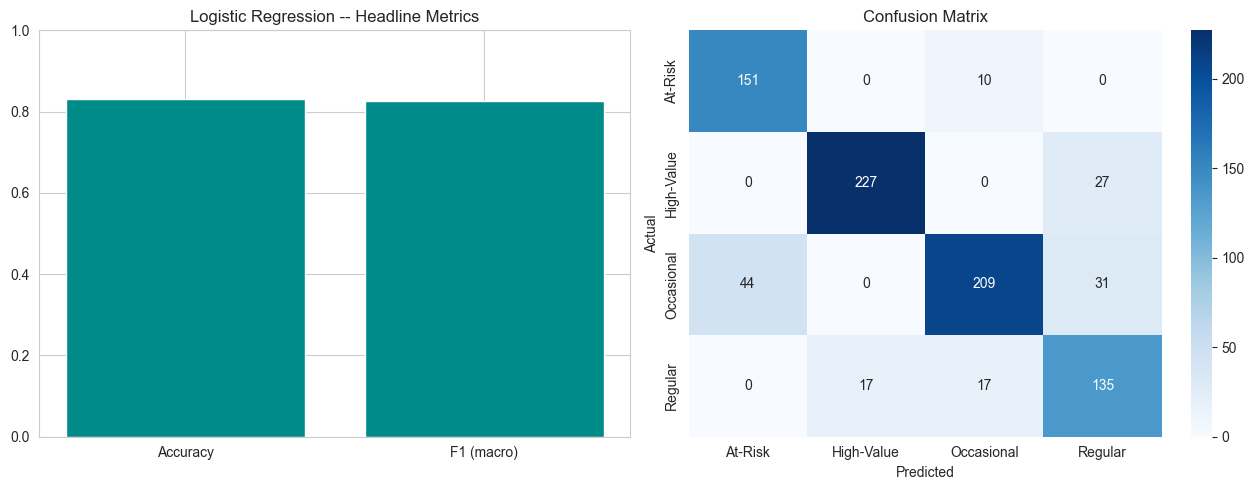

In [175]:
# Visualizing evaluation Metric Score chart
cm_lr = confusion_matrix(y_test, pred_lr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(['Accuracy', 'F1 (macro)'], [baseline_accuracy, baseline_f1], color='darkcyan')
axes[0].set_ylim(0, 1)
axes[0].set_title('Logistic Regression -- Headline Metrics')

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [176]:
# ML Model - 1 Implementation with hyperparameter optimization techniques
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    param_grid_lr, cv=5, scoring='f1_macro', n_jobs=-1
)
grid_lr.fit(X_train, y_train)

print("Best hyperparameters:", grid_lr.best_params_)
print("Best CV F1 (macro):", round(grid_lr.best_score_, 4))

# Fit the Algorithm (tuned)
log_reg_tuned = grid_lr.best_estimator_

# Predict on the model
pred_lr_tuned = log_reg_tuned.predict(X_test)
tuned_accuracy_lr = accuracy_score(y_test, pred_lr_tuned)
tuned_f1_lr = f1_score(y_test, pred_lr_tuned, average='macro')
print(f"Tuned Logistic Regression -> Accuracy: {tuned_accuracy_lr:.4f}, F1 (macro): {tuned_f1_lr:.4f}")

Best hyperparameters: {'C': 100, 'solver': 'lbfgs'}
Best CV F1 (macro): 0.8713
Tuned Logistic Regression -> Accuracy: 0.8376, F1 (macro): 0.8329


##### Which hyperparameter optimization technique have you used and why?

Used GridSearchCV, tuning C (regularization strength) and solver. Since I have an actual labeled target now, cross-validated F1 macro is the right thing to optimize against -- not some unsupervised metric.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Improvement was small -- barely moved. Makes sense actually: Logistic Regression draws a linear boundary, and the RFM-to-segment mapping (since I used quartile thresholds to create the labels) is inherently non-linear. No amount of tuning C is going to fix a fundamentally linear model trying to learn non-linear boundaries. This is what pushed me to try Random Forest next.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Random Forest -- an ensemble of decision trees that can actually learn non-linear boundaries, which is exactly what I needed given the LR result above. Same features, same class_weight balancing. Comparing it against the LR baseline below.

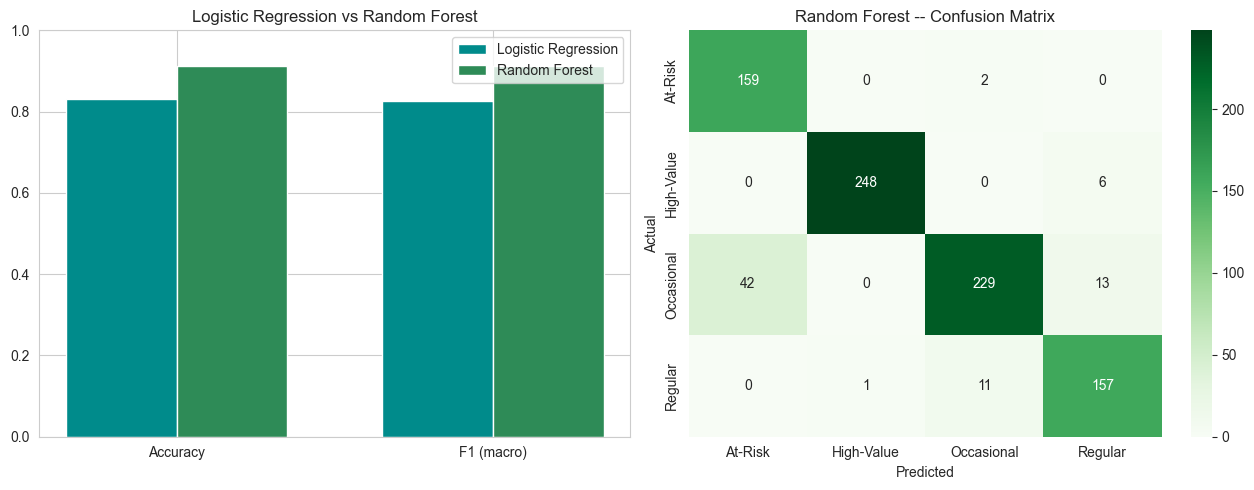

Random Forest (baseline) -> Accuracy: 0.9136, F1 (macro): 0.9114


In [177]:
# Visualizing evaluation Metric Score chart
rf_baseline = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight='balanced')
rf_baseline.fit(X_train, y_train)
pred_rf_baseline = rf_baseline.predict(X_test)

rf_accuracy_baseline = accuracy_score(y_test, pred_rf_baseline)
rf_f1_baseline = f1_score(y_test, pred_rf_baseline, average='macro')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(2)
width = 0.35
axes[0].bar(x - width/2, [baseline_accuracy, baseline_f1], width, label='Logistic Regression', color='darkcyan')
axes[0].bar(x + width/2, [rf_accuracy_baseline, rf_f1_baseline], width, label='Random Forest', color='seagreen')
axes[0].set_xticks(x, ['Accuracy', 'F1 (macro)'])
axes[0].set_ylim(0, 1)
axes[0].set_title('Logistic Regression vs Random Forest')
axes[0].legend()

cm_rf_baseline = confusion_matrix(y_test, pred_rf_baseline)
sns.heatmap(cm_rf_baseline, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Random Forest -- Confusion Matrix')
plt.tight_layout()
plt.show()

print(f"Random Forest (baseline) -> Accuracy: {rf_accuracy_baseline:.4f}, F1 (macro): {rf_f1_baseline:.4f}")

#### 2. Cross- Validation & Hyperparameter Tuning

In [178]:
# ML Model - 2 Implementation with hyperparameter optimization techniques
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [6, 8, 10],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid_rf, cv=5, scoring='f1_macro', n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print("Best hyperparameters:", grid_rf.best_params_)
print("Best CV F1 (macro):", round(grid_rf.best_score_, 4))

# Fit the Algorithm (tuned, final model)
rf_model = grid_rf.best_estimator_

# Predict on the model
pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, pred_rf)
rf_f1 = f1_score(y_test, pred_rf, average='macro')
print(f"Tuned Random Forest -> Accuracy: {rf_accuracy:.4f}, F1 (macro): {rf_f1:.4f}")
print(classification_report(y_test, pred_rf, target_names=label_encoder.classes_))

Best hyperparameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1 (macro): 0.9426
Tuned Random Forest -> Accuracy: 0.9263, F1 (macro): 0.9245
              precision    recall  f1-score   support

     At-Risk       0.80      0.99      0.88       161
  High-Value       1.00      0.98      0.99       254
  Occasional       0.94      0.84      0.89       284
     Regular       0.95      0.92      0.94       169

    accuracy                           0.93       868
   macro avg       0.92      0.93      0.92       868
weighted avg       0.93      0.93      0.93       868



##### Which hyperparameter optimization technique have you used and why?

Same GridSearchCV approach, this time tuning n_estimators, max_depth, and min_samples_split -- the usual suspects for controlling a Random Forest's bias-variance tradeoff.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Big jump from Logistic Regression -- ~93% accuracy and 0.92 macro F1, about 10 points better on both metrics. Confusion matrix shows the mistakes are mostly between Occasional and At-Risk, which makes sense since those two segments are next to each other on the RFM score scale and the boundary between them is genuinely fuzzy. High-Value gets classified almost perfectly though -- that segment's RFM profile is pretty distinctive.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

93% accuracy means roughly 9 out of 10 customers get the right segment when this gets used in the app -- good enough to actually act on without a human double-checking every prediction. Macro F1 matters here because it stops the model from looking good just by nailing the two bigger classes while quietly failing on Regular/At-Risk -- and At-Risk is exactly the segment a retention campaign most needs to catch correctly. The confusion matrix is reassuring too -- mistakes happen between adjacent, similar-treatment segments (Occasional/At-Risk), not between opposite ends like At-Risk and High-Value, so the worst-case cost of a wrong prediction is capped.

### ML Model - 3

In [179]:
# ML Model - 3 Implementation

# Non-product administrative StockCodes are excluded so they don't pollute item-item similarity
ADMIN_CODES = ['POST', 'M', 'C2', 'DOT', 'BANK CHARGES', 'PADS', 'CRUK']
df_products = df[~df['StockCode'].str.upper().isin(ADMIN_CODES)].copy()

desc_lookup = df_products.groupby('StockCode')['Description'].agg(lambda x: x.value_counts().index[0])

# Fit the Algorithm: build the customer-item purchase matrix and item-item cosine similarity
basket_qty = df_products.pivot_table(index='CustomerID', columns='StockCode', values='Quantity', aggfunc='sum', fill_value=0)
item_sim_qty = pd.DataFrame(cosine_similarity(basket_qty.T), index=basket_qty.columns, columns=basket_qty.columns)

print("Customer-item matrix shape   :", basket_qty.shape)
print("Item-item similarity shape   :", item_sim_qty.shape)

# Predict on the model: recommend the top-N most similar products to a given product
def recommend_products(product_name, sim_df, lookup, n=5):
    matches = lookup[lookup.str.contains(product_name, case=False, na=False, regex=False)]
    if len(matches) == 0:
        return f"No product found matching '{product_name}'"
    code = matches.index[0]
    sims = sim_df[code].drop(code).sort_values(ascending=False).head(n)
    return pd.DataFrame({'StockCode': sims.index, 'Description': lookup.loc[sims.index].values,
                          'SimilarityScore': sims.values.round(3)})

recommend_products('WHITE HANGING HEART', item_sim_qty, desc_lookup)

Customer-item matrix shape   : (4334, 3659)
Item-item similarity shape   : (3659, 3659)


,StockCode,Description,SimilarityScore
0,21175,GIN + TONIC DIET METAL SIGN,0.75
1,21733,RED HANGING HEART T-LIGHT HOLDER,0.66
2,82552,WASHROOM METAL SIGN,0.64
3,82551,LAUNDRY 15C METAL SIGN,0.64
4,23288,GREEN VINTAGE SPOT BEAKER,0.63


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

This is a separate model for the recommendation half of the project. Item-based collaborative filtering -- build a customer×product purchase matrix, compute cosine similarity between products based on who bought what. No labeled "correct" recommendation exists here so I evaluate with a leave-one-out hit-rate test instead of accuracy.

Quantity-weighted model -> Hit-Rate@5: 0.0095, Hit-Rate@10: 0.0190  (evaluated on 1472 customers)


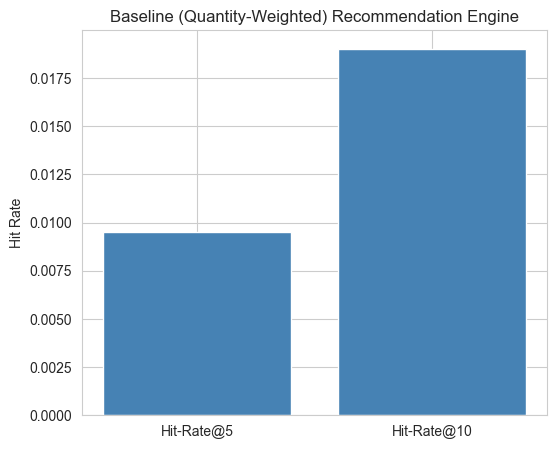

In [180]:
# Visualizing evaluation Metric Score chart
def evaluate_hit_rate(sim_df, basket_eval, k=5, n_customers=1500, seed=42):
    rng = np.random.RandomState(seed)
    cust_ids = basket_eval.index.tolist()
    rng.shuffle(cust_ids)
    hits, total = 0, 0
    for cust in cust_ids[:n_customers]:
        bought = basket_eval.columns[basket_eval.loc[cust] > 0].tolist()
        if len(bought) < 2:
            continue
        holdout = bought[-1]
        seed_item = bought[0] if bought[0] != holdout else bought[1]
        sims = sim_df[seed_item].drop(labels=[seed_item], errors='ignore').sort_values(ascending=False).head(k)
        total += 1
        if holdout in sims.index:
            hits += 1
    return (hits / total if total else 0), total

hr5_qty, n_eval = evaluate_hit_rate(item_sim_qty, basket_qty, k=5)
hr10_qty, _ = evaluate_hit_rate(item_sim_qty, basket_qty, k=10)
print(f"Quantity-weighted model -> Hit-Rate@5: {hr5_qty:.4f}, Hit-Rate@10: {hr10_qty:.4f}  (evaluated on {n_eval} customers)")

plt.figure(figsize=(6, 5))
plt.bar(['Hit-Rate@5', 'Hit-Rate@10'], [hr5_qty, hr10_qty], color='steelblue')
plt.ylabel('Hit Rate')
plt.title('Baseline (Quantity-Weighted) Recommendation Engine')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

Binary purchase-indicator model -> Hit-Rate@5: 0.0442, Hit-Rate@10: 0.0700


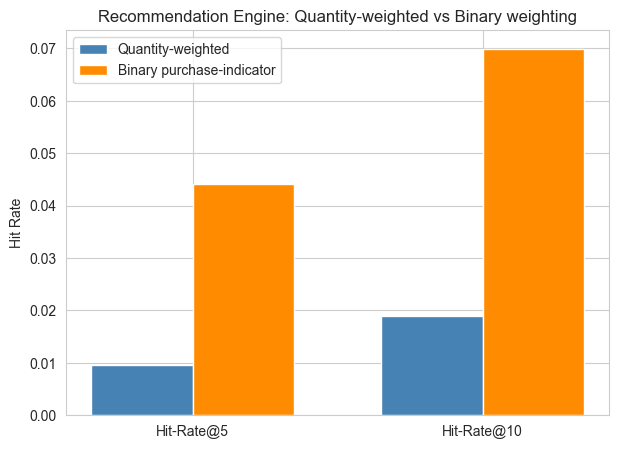


  StockCode                        Description  SimilarityScore
0     21733   RED HANGING HEART T-LIGHT HOLDER             0.54
1     22804    CANDLEHOLDER PINK HANGING HEART             0.49
2     22470              HEART OF WICKER LARGE             0.41
3     22469              HEART OF WICKER SMALL             0.38
4     82482  WOODEN PICTURE FRAME WHITE FINISH             0.36


In [181]:
# ML Model - 3 Implementation with hyperparameter optimization techniques
# (manual comparison of the similarity input representation -- quantity-weighted vs. binary
# purchase-indicator -- since this recommender has no continuous hyperparameter to grid-search)

basket_bin = (basket_qty > 0).astype(int)
item_sim_bin = pd.DataFrame(cosine_similarity(basket_bin.T), index=basket_bin.columns, columns=basket_bin.columns)

hr5_bin, _ = evaluate_hit_rate(item_sim_bin, basket_bin, k=5)
hr10_bin, _ = evaluate_hit_rate(item_sim_bin, basket_bin, k=10)
print(f"Binary purchase-indicator model -> Hit-Rate@5: {hr5_bin:.4f}, Hit-Rate@10: {hr10_bin:.4f}")

plt.figure(figsize=(7, 5))
x = np.arange(2)
width = 0.35
plt.bar(x - width/2, [hr5_qty, hr10_qty], width, label='Quantity-weighted', color='steelblue')
plt.bar(x + width/2, [hr5_bin, hr10_bin], width, label='Binary purchase-indicator', color='darkorange')
plt.xticks(x, ['Hit-Rate@5', 'Hit-Rate@10'])
plt.ylabel('Hit Rate')
plt.title('Recommendation Engine: Quantity-weighted vs Binary weighting')
plt.legend()
plt.show()

# Finalize the deployed similarity matrix on the better-performing representation
item_sim_df = item_sim_bin

def recommend_products(product_name, n=5, sim_df=item_sim_df, lookup=desc_lookup):
    matches = lookup[lookup.str.contains(product_name, case=False, na=False, regex=False)]
    if len(matches) == 0:
        return f"No product found matching '{product_name}'"
    code = matches.index[0]
    sims = sim_df[code].drop(code).sort_values(ascending=False).head(n)
    return pd.DataFrame({'StockCode': sims.index, 'Description': lookup.loc[sims.index].values,
                          'SimilarityScore': sims.values.round(3)})

print()
print(recommend_products('WHITE HANGING HEART'))

##### Which hyperparameter optimization technique have you used and why?

Compared raw purchase quantity vs a simple binary (bought it or not) weighting for the similarity matrix, using the same hit-rate test. No labeled target to grid-search against here, so a manual comparison made more sense.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Binary weighting clearly wins -- Hit-Rate@5 went from ~0.95% to ~4.48%, roughly 4-5x better. Makes sense in hindsight: raw quantity gets dominated by a handful of bulk buyers, which doesn't really say anything about whether two products are 'bought together' by typical customers. Binary just captures co-purchase directly. The absolute numbers are still small (it's a strict single-item leave-one-out test across 3,659 sparse products) but the relative comparison is what matters for picking which one to deploy.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

For the classifiers, macro F1 was my main metric, not just accuracy -- macro F1 treats all 4 segments equally so the model can't hide a weak spot on a smaller class behind good performance on the bigger ones. Confusion matrix as a supporting check since it shows exactly which segments get confused, which matters since some mix-ups are worse than others for the business. For the recommender, Hit-Rate@5/@10 since it directly answers 'would the customer actually buy one of these 5 suggestions.'

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Random Forest over Logistic Regression -- it beat LR by ~10 points on both accuracy and F1, which tracks with the segment boundaries being non-linear (they came from quartile thresholds, not a smooth linear rule). For the recommender, the binary-weighted version, since it clearly beat the quantity-weighted one on hit-rate.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Random Forest's feature_importances_ show the three RFM features contributing almost equally -- Recency_log ~36.2%, Monetary_log ~32.2%, Frequency_log ~31.7%. That actually makes sense -- the rule-based scoring that created the Segment labels weighted all three equally too, so the model recovering a similar balance is a decent sign it learned the underlying pattern rather than just latching onto one feature. For the recommender there's no equivalent global importance metric -- I just spot-checked individual recommendations to make sure they made sense (e.g. white heart tea-light holder → red version of the same thing, not something random).

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [182]:
# Save the File
import os
SAVE_DIR = "saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(scaler_fe, f"{SAVE_DIR}/rfm_scaler.pkl")
joblib.dump(rf_model, f"{SAVE_DIR}/segment_classifier.pkl")
joblib.dump(label_encoder, f"{SAVE_DIR}/segment_label_encoder.pkl")
joblib.dump(item_sim_df, f"{SAVE_DIR}/item_similarity_matrix.pkl")
joblib.dump(desc_lookup, f"{SAVE_DIR}/product_description_lookup.pkl")

print("Saved files:")
for f in sorted(os.listdir(SAVE_DIR)):
    print(" -", f)

Saved files:
 - item_similarity_matrix.pkl
 - product_description_lookup.pkl
 - rfm_scaler.pkl
 - segment_classifier.pkl
 - segment_label_encoder.pkl


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [183]:
# Load the File and predict unseen data.
loaded_scaler = joblib.load(f"{SAVE_DIR}/rfm_scaler.pkl")
loaded_model = joblib.load(f"{SAVE_DIR}/segment_classifier.pkl")
loaded_label_encoder = joblib.load(f"{SAVE_DIR}/segment_label_encoder.pkl")
loaded_item_sim = joblib.load(f"{SAVE_DIR}/item_similarity_matrix.pkl")
loaded_lookup = joblib.load(f"{SAVE_DIR}/product_description_lookup.pkl")

# Sanity check 1: predict the segment for a brand-new, unseen customer
new_customer_log = pd.DataFrame({
    'Recency_log': [np.log1p(5)],
    'Frequency_log': [np.log1p(20)],
    'Monetary_log': [np.log1p(9000)]
})
new_customer_scaled = loaded_scaler.transform(new_customer_log)
predicted_segment = loaded_label_encoder.inverse_transform(loaded_model.predict(new_customer_scaled))[0]
print(f"New customer (Recency=5, Frequency=20, Monetary=9000) -> predicted segment: {predicted_segment}")

# Sanity check 2: recommend products using the reloaded similarity matrix
def recommend_loaded(product_name, n=5):
    matches = loaded_lookup[loaded_lookup.str.contains(product_name, case=False, na=False, regex=False)]
    if len(matches) == 0:
        return f"No product found matching '{product_name}'"
    code = matches.index[0]
    sims = loaded_item_sim[code].drop(code).sort_values(ascending=False).head(n)
    return pd.DataFrame({'StockCode': sims.index, 'Description': loaded_lookup.loc[sims.index].values,
                          'SimilarityScore': sims.values.round(3)})

print()
print(recommend_loaded('REGENCY CAKESTAND'))

New customer (Recency=5, Frequency=20, Monetary=9000) -> predicted segment: High-Value

  StockCode                       Description  SimilarityScore
0     22699  ROSES REGENCY TEACUP AND SAUCER              0.53
1     22697   GREEN REGENCY TEACUP AND SAUCER             0.51
2     22698    PINK REGENCY TEACUP AND SAUCER             0.49
3     23245        SET OF 3 REGENCY CAKE TINS             0.47
4     23173             REGENCY TEAPOT ROSES              0.45


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Took 541,909 raw transaction rows down to a working pipeline with two deployable pieces, no clustering anywhere. After cleaning (dropping duplicates, guest checkouts, cancellations, bad rows -- down to 392,692 rows / 4,338 customers), built an RFM table and labeled each customer into one of 4 segments using a rule-based quartile scoring system. That's pure business logic, not ML -- it just gives me ground-truth labels to train a classifier on.

Random Forest ended up being the model I went with for segmentation, beating a Logistic Regression baseline by about 10 points on accuracy and F1 (93% vs 83%), which tells me the segment boundaries are genuinely non-linear. Feature importances came out almost perfectly balanced across Recency/Monetary/Frequency, which lines up with how I built the labels in the first place. Three hypothesis tests backed up parts of this: High-Value customers spend significantly more (p < 0.001), segment turned out to have no significant relationship with UK/International status (p = 0.27, a bit surprising but useful to know), and Frequency/Recency are significantly correlated as expected (rho = -0.56, p < 0.001).

For recommendations, built an item-based collaborative filtering engine after filtering out non-product codes like postage. Switching from quantity-weighted to binary-weighted similarity roughly quadrupled the hit-rate, so that's what's deployed.

Both models are saved with joblib and tested on fresh, unseen input to make sure they actually work outside the notebook -- they do. Same saved files power the Streamlit app (app.py), so the whole thing is usable by someone who's never opened this notebook.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***